<a href="https://colab.research.google.com/github/nisanurkesim/golden-section-search-optimization/blob/main/YapayZekaOptimizasyonu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Eser Satışında Kar Maksimizasyonu Problem Tanımı**

Bir sahaf dükkanında, özel koleksiyon bir serinin satış fiyatını ($x$, bin TL cinsinden) belirlememiz gerekmektedir. Fiyatlandırma stratejisine bağlı olarak beklenen kar fonksiyonu aşağıdaki gibi modellenmiştir:

$$
f(x) = -2.1x^2 + 84.4x - 150
$$

Amacımız, **10 bin TL ile 30 bin TL** fiyat aralığında bu fonksiyonu maksimize eden optimum satış fiyatını ($x$) bulmaktır.  
Çözüm için **Altın Oran Arama (Golden Section Search)** algoritması kullanılmıştır, kabul edilebilir hata payı (belirsizlik aralığı) $\epsilon = 0.1$ olarak belirlenmiştir.

---

## **Belirsizlik Aralığı ve İterasyon Sayısının Belirlenmesi**

Algoritmanın optimum noktaya ne kadar yaklaştığını kontrol etmek için kabul edilebilir maksimum belirsizlik aralığı $\epsilon = 0.1$ olarak belirlenmiştir.  
Altın Oran Arama algoritmasında $k$'ncı iterasyon sonunda belirsizlik aralığının uzunluğu aşağıdaki formülle ifade edilir:

$$
L_k = r^k (b - a)
$$

Arama işleminin sonlandırılabilmesi için son belirsizlik aralığının $\epsilon$'dan küçük olması gerekir:

$$
r^k (b - a) < \epsilon
$$

Problemimizdeki değerleri formülde yerine koyarsak yapılması gereken iterasyon sayısı şu şekilde hesaplanır:

$$
0.618^k (30 - 10) < 0.1
$$

$$
0.618^k (20) < 0.1
$$

$$
0.618^k < 0.005
$$

Eşitsizliğin her iki tarafının doğal logaritması ($\ln$) alınırsa:

$$
k \ln(0.618) < \ln(0.005)
$$

$$
k(-0.481) < -5.298
$$

$$
k > 11.01
$$

Bu hesaplamalara göre, optimum satış fiyatını **0.1 hassasiyetle** bulabilmek için algoritmanın yaklaşık **12 iterasyon** çalıştırılması gerektiğini bulduk.

---

## **Çözüm Yöntemi ve Algoritma Mantığı**

Algoritma her adımda belirsizlik aralığını, $r^2 + r = 1$ denkleminin pozitif kökü olan **altın oran sabiti** ($r \approx 0.618$) ile daraltacaktır.

Başlangıç aralığımız $[a, b]$ için her iterasyonda iki yeni test noktası hesaplanır:

- **Birinci test noktası:**  
  $$x_1 = b - r(b - a)$$

- **İkinci test noktası:**  
  $$x_2 = a + r(b - a)$$

Maksimizasyon probleminde $f(x_1)$ ve $f(x_2)$ değerleri karşılaştırırız:

- Eğer $f(x_1) < f(x_2)$ ise, optimum çözümün $x_1$'in solunda olma olasılığı elenir ve yeni aralık $(x_1, b]$ olarak güncellenir.
- Eğer $f(x_1) \ge f(x_2)$ ise, optimum çözüm sağ tarafta olamayacağı için yeni aralık $[a, x_2)$ olarak belirlenir.

---

## **Adım Adım İterasyon Çözümlemesi**
### 1. İterasyon

**Mevcut aralık:**  
$$[a, b] = [10, 30]$$

**Test noktalarının hesaplanması:**

$$x_1 = 30 - 0.618(30 - 10) \approx 17.64$$

$$x_2 = 10 + 0.618(30 - 10) \approx 22.36$$

**Fonksiyon değerleri:**

$$f(17.64) = -2.1(17.64)^2 + 84.4(17.64) - 150 \approx 685.36$$

$$f(22.36) = -2.1(22.36)^2 + 84.4(22.36) - 150 \approx 687.25$$

**Değerlendirme:**

$f(17.64) < f(22.36)$ olduğu için fonksiyon $x_1$ ile $x_2$ arasında artış eğilimindedir.  
Bu sebeple optimum nokta **[10, 17.64]** aralığında oluşamaz.  
Alt sınır güncellenir ve yeni belirsizlik aralığı **[17.64, 30]** olur.

---

### 2. İterasyon

**Mevcut aralık:**  
$$[a, b] = [17.64, 30]$$

**Test noktalarının hesaplanması:**

Bir önceki adımdaki $x_2$ noktası yeni adımın $x_1$ noktası olarak doğrudan kullanılır:

$$x_1 \approx 22.36 \quad (\text{önceki iterasyondan})$$

$$x_2 = 17.64 + 0.618(30 - 17.64) \approx 25.28$$

**Fonksiyon değerleri:**

$$f(22.36) \approx 687.25$$

$$f(25.28) = -2.1(25.28)^2 + 84.4(25.28) - 150 \approx 641.57$$

**Değerlendirme:**

Bu aşamada $f(22.36) > f(25.28)$ bulunmuştur.  
Fonksiyon $x_2$'ye ulaşmadan önce azalmaya başlamıştır.  
Dolayısıyla üst sınır daraltılır ve yeni belirsizlik aralığı **[17.64, 25.28]** olur.

---

### 3. İterasyon

**Mevcut aralık:**  
$$[a, b] = [17.64, 25.28]$$

**Test noktalarının hesaplanması:**

Bir önceki adımdaki $x_1$ noktası yeni adımın $x_2$ noktası olarak kullanılır.

$$x_2 \approx 22.36 \quad (\text{önceki iterasyondan})$$

$$x_1 = 25.28 - 0.618(25.28 - 17.64) \approx 20.56$$

**Fonksiyon değerleri:**

$$f(20.56) = -2.1(20.56)^2 + 84.4(20.56) - 150 \approx 697.57$$

$$f(22.36) \approx 687.25$$

**Değerlendirme:**

$f(20.56) > f(22.36)$ olduğu için optimum nokta $x_2$'nin solunda aranmalıdır.  
Üst sınır daraltılır ve yeni belirsizlik aralığı **[17.64, 22.36]** olur.

---

Algoritma yukarıdaki gibi devam eder ve 12. iterasyonda aralık boyutu 0.1'in altına düştüğünde işlem durur.  
Bu noktada optimum satış fiyatını elde etmiş olacağız.

In [ ]:
import math

def kar_fonksiyonu(x):
    #kar fonksiyonu: f(x) = -2.1x^2 + 84.4x - 150
    return -2.1 * x**2 + 84.4 * x - 150


def golden_section_maximize(a, b, epsilon=0.1):
    r = (math.sqrt(5) - 1) / 2  # Altın oran sabiti (~0.618)
    iteration = 0  # printi döngünün başına koyduğum için iterasyonu 0'dan başlattım.

    print("SAHAF KAR MAKSİMİZASYONU İTERASYON TABLOSU")
    print(f"{'Iter':<5} | {'a':<8} | {'b':<8} | {'x1':<8} | {'x2':<8} | "
          f"{'f(x1)':<10} | {'f(x2)':<10} | {'Hata (b-a)':<10}")
    print("-" * 90)

    # Başlangıç noktaları
    x1 = b - r * (b - a)
    x2 = a + r * (b - a)
    fx1 = kar_fonksiyonu(x1)
    fx2 = kar_fonksiyonu(x2)

    # Altın Oran Arama Döngüsü
    while (b - a) >= epsilon:
        iteration += 1
        print(f"{iteration:<5} | {a:<8.4f} | {b:<8.4f} | {x1:<8.4f} | {x2:<8.4f} | "
              f"{fx1:<10.4f} | {fx2:<10.4f} | {(b - a):<10.4f}")
        if fx1 < fx2:
            a = x1
            x1, fx1 = x2, fx2
            x2 = a + r * (b - a)
            fx2 = kar_fonksiyonu(x2)
        else:
            b = x2
            x2, fx2 = x1, fx1
            x1 = b - r * (b - a)
            fx1 = kar_fonksiyonu(x1)

    # Sonuçlar:
    optimal_x = (a + b) / 2
    max_kar = kar_fonksiyonu(optimal_x)

    print("-" * 90)
    print(f"\nAlgoritma {iteration} iterasyon sonucunda tamamlandı")
    print(f"Optimum Satış Fiyatı (x): {optimal_x:.4f} Bin TL")
    print(f"Maksimum Beklenen Kar f(x): {max_kar:.4f} Bin TL")


# Fonksiyonu çalıştırma
golden_section_maximize(a=10, b=30, epsilon=0.1)

SAHAF KAR MAKSİMİZASYONU İTERASYON TABLOSU
Iter  | a        | b        | x1       | x2       | f(x1)      | f(x2)      | Hata (b-a)
------------------------------------------------------------------------------------------
1     | 10.0000  | 30.0000  | 17.6393  | 22.3607  | 685.3528   | 687.2414   | 20.0000   
2     | 17.6393  | 30.0000  | 22.3607  | 25.2786  | 687.2414   | 641.5970   | 12.3607   
3     | 17.6393  | 25.2786  | 20.5573  | 22.3607  | 697.5707   | 687.2414   | 7.6393    
4     | 17.6393  | 22.3607  | 19.4427  | 20.5573  | 697.1249   | 697.5707   | 4.7214    
5     | 19.4427  | 22.3607  | 20.5573  | 21.2461  | 697.5707   | 695.2375   | 2.9180    
6     | 19.4427  | 21.2461  | 20.1316  | 20.5573  | 698.0163   | 697.5707   | 1.8034    
7     | 19.4427  | 20.5573  | 19.8684  | 20.1316  | 697.9110   | 698.0163   | 1.1146    
8     | 19.8684  | 20.5573  | 20.1316  | 20.2942  | 698.0163   | 697.9359   | 0.6888    
9     | 19.8684  | 20.2942  | 20.0311  | 20.1316  | 698.0104   | 

## **Sonuçların Değerlendirilmesi**

Algoritma çıktısına göre:
- Optimum satış fiyatı **20.1005 Bin TL** 'dir ve
- Maksimum beklenen kar ise  **698.0190 Bin TL** olarak hesaplanmıştır.

Fonksiyonun türevini sıfıra eşitlediğimizde:
$$
f'(x) = -4.2x + 84.4 = 0 \Rightarrow x = 20.1
$$
çıktısını elde ediyoruz. Bu sonuç 0.1 hata payı içerisinde olduğu için algoritma sorunsuz diyebiliriz.

Bundan yola çıkarak söyleyebiliriz ki, sahaf dükkanının nadir eser koleksiyonu
için belirlenen yaklaşık 20.10 Bin TL satış fiyatı, beklenen karı maksimum
düzeye çıkaran optimum fiyat olduğu görülür. Bu fiyatın altında belirlenen bir
fiyat, müşteri talebini artırsa da elde edilecek kar miktarını düşürecektir.
Benzer şekilde bu fiyatın üzerinde belirlenen bir fiyat ise müşteri kaybına yol
açarak yine karın azalmasına neden olabilir. Dolayısıyla dükkan sahibi açısından
en mantıklı fiyatlandırma kararı, algoritmanın bulduğu bu optimum noktadır.


# **Yavru Fil Büyüme Modelinde Hata Minimizasyonu Problem Tanımı**

Bir vahşi yaşam koruma parkında, yavru Asya fillerinin sağlıklı büyümesi için günlük almaları gereken özel bir besin takviyesi miktarı ($x$, kilogram cinsinden) hesaplanmaktadır.  
İdeal büyüme eğrisinden sapmayı gösteren fonksiyon aşağıdaki gibi modellenmiştir:

$$
E(x) = 1.2x^2 - 7.6x + 15
$$

Amacımız, 0 kg ile 6 kg aralığında, ideal büyüme eğrisinden sapmayı (hatayı) minimize eden optimum günlük takviye miktarını bulmak olacaktır.  
Çözüm yöntemi olarak **Altın Oran Arama (Golden Section Search)** algoritmasını kullanacağız.

---

## **Belirsizlik Aralığı ve İterasyon Sayısının Belirlenmesi**

Hata payımız $\epsilon = 0.1$ olarak belirlenmiştir. Bu değer, optimum besin miktarının **0.1 kg hassasiyetle** tespit edilmesinin
yeterli olduğu kabulüne dayanmaktadır.
Aralığın uzunluğunun bu değerin altına düşmesi için gereken iterasyon sayısı şöyle hesaplanır:

$$
r^k (b - a) < \epsilon
$$

$$
0.618^k (6 - 0) < 0.1
$$

$$
0.618^k < 0.0166
$$

$$
k \ln(0.618) < \ln(0.0166)
$$

$$
k(-0.481) < -4.098
$$

$$
k > 8.51
$$

Bu çözümler bize, optimum besin miktarını **0.1 hassasiyetle** bulabilmek için algoritmanın yaklaşık **9 iterasyon** çalıştırılması gerektiğini göstermiştir.

---

## **Çözüm Yöntemi ve Dönüşüm**

Altın Oran Arama algoritması temelde maksimizasyon prensibiyle çalıştığını biliyoruz.  
Minimizasyon problemlerinde algoritmayı kullanabilmek için de amaç fonksiyonu $-1$ ile çarparak minimizasyon fonksiyonumuzu kurmuş oluyoruz.  
Bu durumda:

$$
g(x) = -1.2x^2 + 7.6x - 15
$$

çünkü:

$$
\min f(x) = -\max(-f(x))
$$

Böylece, dönüştürülmüş $g(x)$ fonksiyonunun maksimumunu arayarak, orijinal hata fonksiyonunun minimum noktasını tespit etmesini sağladık.

---

## **Adım Adım İterasyon Çözümlemesi**
### 1. İterasyon

**Mevcut aralık:**
$$[a, b] = [0, 6]$$

**Test noktalarının hesaplanması:**

$$x_1 = 6 - 0.618(6 - 0) \approx 2.2918$$

$$x_2 = 0 + 0.618(6 - 0) \approx 3.7082$$

**Fonksiyon değerleri:**

$$E(x_1) = 1.2(2.2918)^2 - 7.6(2.2918) + 15 \approx 3.8851$$

$$E(x_2) = 1.2(3.7082)^2 - 7.6(3.7082) + 15 \approx 3.3186$$

**Dönüştürülmüş değerler** ($g(x) = -E(x)$):

$$g(x_1) \approx -3.8851 \qquad g(x_2) \approx -3.3186$$

**Değerlendirme:**

$g(x_1) < g(x_2)$ olduğu için optimum nokta $x_1$'in sağında olacak.  
Alt sınır: yeni aralık $[2.2918, \ 6]$ olur.

---

### 2. İterasyon

**Mevcut aralık:**
$$[a, b] = [2.2918, 6]$$

**Test noktalarının hesaplanması:**

Bir önceki adımdaki $x_2$ noktası yeni adımın $x_1$ noktası olarak kullanırız:

$$x_1 \approx 3.7082 \quad (\text{önceki iterasyondan})$$

$$x_2 = 2.2918 + 0.618(6 - 2.2918) \approx 4.5836$$

**Fonksiyon değerleri:**

$$E(x_1) = E(3.7082) \approx 3.3186$$

$$E(x_2) = 1.2(4.5836)^2 - 7.6(4.5836) + 15 \approx 5.3759$$

**Dönüştürülmüş değerler:**

$$g(x_1) \approx -3.3186 \qquad g(x_2) \approx -5.3759$$

**Değerlendirme:**

$g(x_1) > g(x_2)$ olduğu için optimum nokta $x_2$'nin solunda olacak.  
Üst sınır: yeni aralık $[2.2918, \ 4.5836]$ olur.

---

### 3. İterasyon

**Mevcut aralık:**
$$[a, b] = [2.2918, 4.5836]$$

**Test noktalarının hesaplanması:**

Bir önceki adımdaki $x_1$ noktası yeni adımın $x_2$ noktası olarak kullanılır:

$$x_2 \approx 3.7082 \quad (\text{önceki iterasyondan})$$

$$x_1 = 4.5836 - 0.618(4.5836 - 2.2918) \approx 3.1672$$

**Fonksiyon değerleri:**

$$E(x_1) = 1.2(3.1672)^2 - 7.6(3.1672) + 15 \approx 2.9667$$

$$E(x_2) = E(3.7082) \approx 3.3186$$

**Dönüştürülmüş değerler:**

$$g(x_1) \approx -2.9667 \qquad g(x_2) \approx -3.3186$$

**Değerlendirme:**

$g(x_1) > g(x_2)$ olduğu için optimum nokta $x_2$'nin solunda olacak.  
Üst sınır : yeni aralık $[2.2918, \ 3.7082]$ olur.

---

Algoritma yukarıda gösterilen mantıkla devam eder ve 9. iterasyonda aralık boyutu 0.1'in altına düştüğünde işlem durur.  
Bu noktada optimum besin takviyesi miktarı elde edilmiş olur.

In [ ]:
import math

def fil_hata_fonksiyonu(x):
    #Yavru fillerin büyüme modelindeki hata fonksiyonu: E(x) = 1.2x^2 - 7.6x + 15
    return 1.2 * x**2 - 7.6 * x + 15


def golden_section_minimize(a, b, epsilon=0.1):
    r = (math.sqrt(5) - 1) / 2  # Altın oran sabiti (~0.618)
    iteration = 0

    print("YAVRU FİL BÜYÜME HATA MİNİMİZASYONU İTERASYON TABLOSU")
    print(f"{'Iter':<5} | {'a':<8} | {'b':<8} | {'x1':<8} | {'x2':<8} | "
          f"{'g(x1)':<10} | {'g(x2)':<10} | {'Hata (b-a)':<10}")
    print("-" * 90)

    # Başlangıç noktaları
    x1 = b - r * (b - a)
    x2 = a + r * (b - a)
    fx1 = -1 * fil_hata_fonksiyonu(x1)
    fx2 = -1 * fil_hata_fonksiyonu(x2)

    # Altın Oran Arama Döngüsü
    while (b - a) >= epsilon:
        iteration += 1
        print(f"{iteration:<5} | {a:<8.4f} | {b:<8.4f} | {x1:<8.4f} | {x2:<8.4f} | "
              f"{fx1:<10.4f} | {fx2:<10.4f} | {(b - a):<10.4f}")
        if fx1 < fx2:
            a = x1
            x1, fx1 = x2, fx2
            x2 = a + r * (b - a)
            fx2 = -1 * fil_hata_fonksiyonu(x2)
        else:
            b = x2
            x2, fx2 = x1, fx1
            x1 = b - r * (b - a)
            fx1 = -1 * fil_hata_fonksiyonu(x1)

    # Sonuçların hesaplanması:
    optimal_x = (a + b) / 2
    min_hata = fil_hata_fonksiyonu(optimal_x)

    print("-" * 90)
    print(f"\nAlgoritma {iteration} iterasyon sonucunda tamamlandı.")
    print(f"Optimum Besin Takviyesi (x): {optimal_x:.4f} kg")
    print(f"Minimum Model Hatası E(x): {min_hata:.4f}")


# Fonksiyonu kullanıyoruz
golden_section_minimize(a=0, b=6, epsilon=0.1)

YAVRU FİL BÜYÜME HATA MİNİMİZASYONU İTERASYON TABLOSU
Iter  | a        | b        | x1       | x2       | g(x1)      | g(x2)      | Hata (b-a)
------------------------------------------------------------------------------------------
1     | 0.0000   | 6.0000   | 2.2918   | 3.7082   | -3.8851    | -3.3186    | 6.0000    
2     | 2.2918   | 6.0000   | 3.7082   | 4.5836   | -3.3186    | -5.3759    | 3.7082    
3     | 2.2918   | 4.5836   | 3.1672   | 3.7082   | -2.9667    | -3.3186    | 2.2918    
4     | 2.2918   | 3.7082   | 2.8328   | 3.1672   | -3.1004    | -2.9667    | 1.4164    
5     | 2.8328   | 3.7082   | 3.1672   | 3.3738   | -2.9667    | -3.0182    | 0.8754    
6     | 2.8328   | 3.3738   | 3.0395   | 3.1672   | -2.9861    | -2.9667    | 0.5410    
7     | 3.0395   | 3.3738   | 3.1672   | 3.2461   | -2.9667    | -2.9742    | 0.3344    
8     | 3.0395   | 3.2461   | 3.1184   | 3.1672   | -2.9695    | -2.9667    | 0.2067    
9     | 3.1184   | 3.2461   | 3.1672   | 3.1973   | -2

## **Sonuçların Değerlendirilmesi**

Altın Oran Arama algoritması, yapılan 9 iterasyon sonunda hata payını **ε = 0.1** seviyesinin altına indirerek yakınsamayı sağlamış olarak gözüküyor.

Elde edilen sonuçlar:
- Optimum günlük besin takviyesi miktarı: **x ≈ 3.1579 kg**  
- Minimum model hatası: **E(x) ≈ 2.9668**

Analitik Doğrulama yapmamız gerekirse;

Fonksiyonun türevi sıfıra eşitlendiğinde

$$
E'(x) = 2.4x - 7.6 = 0 \Rightarrow x = 3.166
$$

İkinci türev değeri:

$$
E''(x) = 2.4 > 0
$$

olduğu için bu nokta fonksiyonun minimum noktasıdır denir.  
Algoritmanın bulduğu **3.1579** değeri analitik çözüm olan **3.166** ile arasındaki fark **|3.1579 − 3.1667| ≈ 0.0088 < ε** olduğundan, sonuçlar hata toleransı içinde doğrudur diyebiliriz.


Sonuç olarak; vahşi yaşam koruma parkındaki yavru Asya
fillerine günlük yaklaşık 3.16 kg besin takviyesi verilmesi ideal
bulunmuştur. Bu miktarın altında verilen takviye, filin yeterli besin
alamayarak olması gereken büyüme eğrisinin gerisinde kalmasına neden olabilir.
Aynı şekilde bu miktarın üzerinde verilen takviye ise aşırı beslenmeye
bağlı sağlık sorunlarına yol açarak yine ideal büyüme eğrisinden sapmaya
neden olabilir. Her iki durumda da hata fonksiyonu E(x) artacak ve filin
sağlıklı gelişimi olumsuz etkilenecektir.

## **Optimizasyon Sonuçlarının Grafiği**

Aşağıdaki grafikler, her iki problemde Altın Oran Arama algoritmasının ulaştığı optimum noktaları göstermektedir.

- **Sol grafik:** Kar fonksiyonunun maksimum noktasını,
- **Sağ grafik:** Hata fonksiyonunun minimum noktasını göstermektedir.


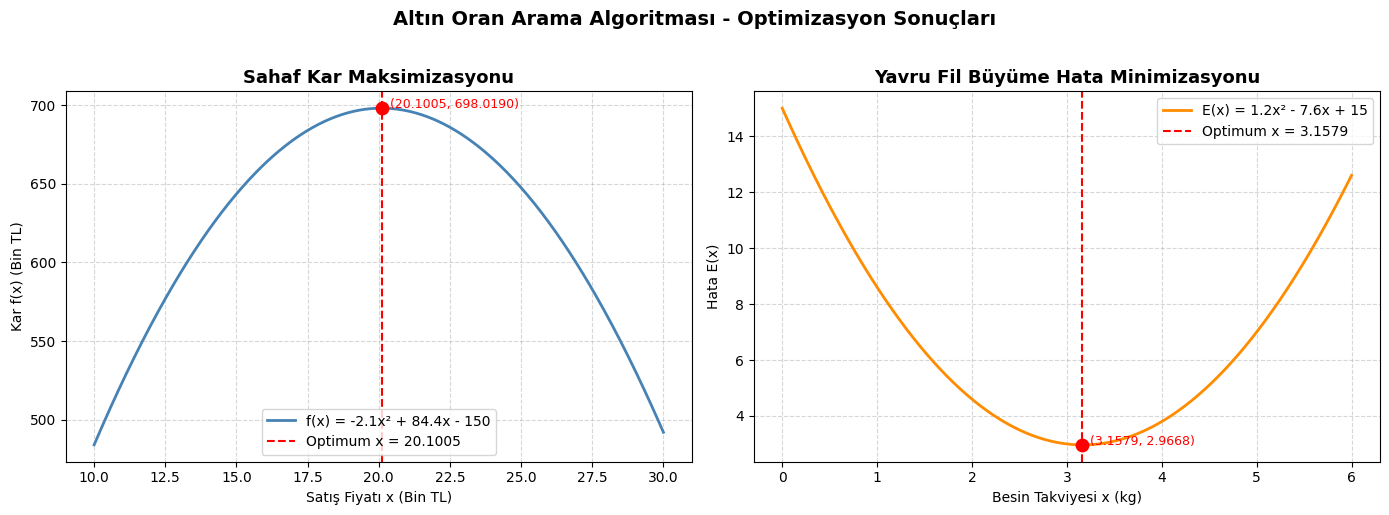

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# kar maksimizasyonu problemi için:
x1 = np.linspace(10, 30, 500)
y1 = -2.1 * x1**2 + 84.4 * x1 - 150

optimal_x1 = 20.1005
optimal_y1 = kar_fonksiyonu(optimal_x1)

axes[0].plot(x1, y1, color='steelblue', linewidth=2, label='f(x) = -2.1x² + 84.4x - 150')
axes[0].axvline(x=optimal_x1, color='red', linestyle='--', linewidth=1.5, label=f'Optimum x = {optimal_x1:.4f}')
axes[0].scatter([optimal_x1], [optimal_y1], color='red', zorder=5, s=80)
axes[0].annotate(f'  ({optimal_x1:.4f}, {optimal_y1:.4f})',
                 xy=(optimal_x1, optimal_y1),
                 fontsize=9, color='red')
axes[0].set_title('Sahaf Kar Maksimizasyonu', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Satış Fiyatı x (Bin TL)')
axes[0].set_ylabel('Kar f(x) (Bin TL)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# minimizasyon problemi için:
x2 = np.linspace(0, 6, 500)
y2 = 1.2 * x2**2 - 7.6 * x2 + 15

optimal_x2 = 3.1579
optimal_y2 = fil_hata_fonksiyonu(optimal_x2)

axes[1].plot(x2, y2, color='darkorange', linewidth=2, label='E(x) = 1.2x² - 7.6x + 15')
axes[1].axvline(x=optimal_x2, color='red', linestyle='--', linewidth=1.5, label=f'Optimum x = {optimal_x2:.4f}')
axes[1].scatter([optimal_x2], [optimal_y2], color='red', zorder=5, s=80)
axes[1].annotate(f'  ({optimal_x2:.4f}, {optimal_y2:.4f})',
                 xy=(optimal_x2, optimal_y2),
                 fontsize=9, color='red')
axes[1].set_title('Yavru Fil Büyüme Hata Minimizasyonu', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Besin Takviyesi x (kg)')
axes[1].set_ylabel('Hata E(x)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Altın Oran Arama Algoritması - Optimizasyon Sonuçları',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Yukarıdaki grafikler, her iki problemde Altın Oran Arama algoritmasının
ulaştığı optimum noktaları göstermektedir.

Sol grafikte kar fonksiyonu f(x) incelendiğinde, eğrinin 20.1005 Bin TL
satış fiyatında tepe noktasına ulaştığı ve bu noktadan sonra her iki yönde
de azaldığı görülüyor. Bu durum, fonksiyonun bu aralıkta
unimodal yapıda olduğunu ve algoritmanın doğru bölgeye yakınsadığını
göstermektedir.

Sağ grafikte ise hata fonksiyonu E(x) incelendiğinde, eğrinin 3.1579 kg
besin takviyesi noktasında dip değerine ulaştığı görülmektedir. Bu noktanın
sola veya sağa kayması, hata değerinin artmasına yol açmaktadır. Bu da
algoritmanın minimum noktayı doğru şekilde tespit ettiğini göstermektedir.

Her iki grafikte de kırmızı kesik çizgi ve nokta ile işaretlenen optimum
noktalar, algoritmanın yalnızca fonksiyon değerlerini karşılaştırarak
türev hesabı yapmaksızın bu sonuçlara ulaşabildiğini görsel olarak
kanıtlamaktadır.